Using the 'cars' dataset, create a scatter plot where the first variable is speed and the second is stopping distance. Fit a linear regression line to it and plot this line on the graph. Then, fit and plot a quadratic function.

The data give the speed of cars and the distances taken to stop. Note that the data were recorded in the 1920s.

1. Ezekiel, M. (1930) Methods of Correlation Analysis. Wiley.
2. McNeil, D. R. (1977) Interactive Data Analysis. Wiley.

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           1.49e-12
Time:                        20:06:29   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.5791      6.758     -2.601      0.0

,speed,dist,pred_linear_lower,pred_linear_upper,pred_quadratic_lower,pred_quadratic_upper,fits_linear,fits_quadratic,color
0,4,2,-12.329543,8.630624,-8.665329,24.110603,True,True,violet
1,4,10,-12.329543,8.630624,-8.665329,24.110603,False,True,blue
2,7,4,1.678977,18.216556,4.154858,23.367455,True,False,green
3,7,22,1.678977,18.216556,4.154858,23.367455,False,True,blue
4,8,16,6.307527,21.452823,8.100923,24.246745,True,True,violet
5,9,10,10.905120,24.720047,11.845147,25.727713,False,False,black
6,10,18,15.461917,28.028068,15.392573,27.805316,True,True,violet
7,10,26,15.461917,28.028068,15.392573,27.805316,True,True,violet
8,10,34,15.461917,28.028068,15.392573,27.805316,False,False,black
9,11,17,19.964525,31.390278,18.796142,30.426613,False,False,black


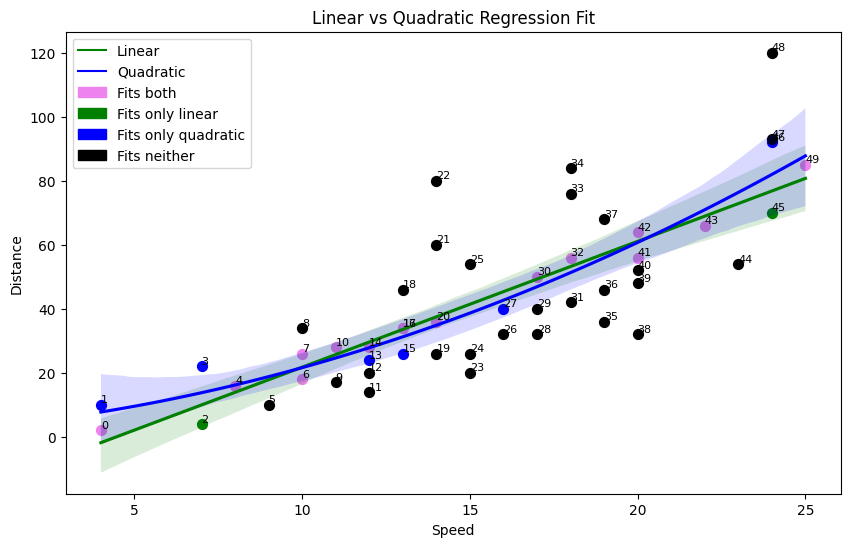

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

df = pd.read_csv('../data/cars.csv')

model_linear = smf.ols(formula = 'dist ~ speed', data = df).fit()
print(model_linear.summary())
model_quadratic = smf.ols(formula = 'dist ~ speed + I(speed**2)', data = df).fit()
print(model_quadratic.summary())

# Przedziały ufności dla średniej wytyczonej przez model liniowy
pred_linear = model_linear.get_prediction(df)
pred_linear_summary = pred_linear.summary_frame(alpha=0.05)
df['pred_linear_lower'] = pred_linear_summary['mean_ci_lower']
df['pred_linear_upper'] = pred_linear_summary['mean_ci_upper']

# Przedziały ufności dla średniej wytyczonej przez model kwadratowy
pred_quadratic = model_quadratic.get_prediction(df)
pred_quadratic_summary = pred_quadratic.summary_frame(alpha=0.05)
df['pred_quadratic_lower'] = pred_quadratic_summary['mean_ci_lower']
df['pred_quadratic_upper'] = pred_quadratic_summary['mean_ci_upper']

# Klasyfikacja punktów na podstawie przedziałów ufności
df['fits_linear'] = (df['dist'] >= df['pred_linear_lower']) & (df['dist'] <= df['pred_linear_upper'])
df['fits_quadratic'] = (df['dist'] >= df['pred_quadratic_lower']) & (df['dist'] <= df['pred_quadratic_upper'])

# Przydział kolorów na podstawie kategorii dopasowania
def get_color(row):
    if row['fits_linear'] and row['fits_quadratic']:
        return 'violet'
    elif row['fits_linear']:
        return 'green'
    elif row['fits_quadratic']:
        return 'blue'
    else:
        return 'black'

df['color'] = df.apply(get_color, axis=1)

display(df)

plt.figure(figsize=(10, 6))
for color in ['violet', 'green', 'blue', 'black']:
    subset = df[df['color'] == color]
    plt.scatter(subset['speed'], subset['dist'], c=color, s=50)

# Przypisanie indeksów do punktów pomiaru
for idx, row in df.iterrows():
    plt.annotate(idx, (row['speed'], row['dist']), fontsize=8, ha='left', va='bottom')

quadratic = {
    'color': 'blue',
    'label': 'Quadratic'
}
linear = {
    'color': 'green',
    'label': 'Linear'
}

sns.regplot(
    x = 'speed',
    y = 'dist',
    data=df,
    scatter = False,
    **linear
)
sns.regplot(
    x = 'speed',
    y = 'dist',
    data = df,
    order = 2,
    scatter = False,
    **quadratic
)

linear_line = mlines.Line2D([], [], **linear)
quadratic_line = mlines.Line2D([], [], **quadratic)
violet_patch = mpatches.Patch(color='violet', label='Fits both')
green_patch = mpatches.Patch(color='green', label='Fits only linear')
blue_patch = mpatches.Patch(color='blue', label='Fits only quadratic')
black_patch = mpatches.Patch(color='black', label='Fits neither')

plt.legend(handles=[linear_line, quadratic_line, violet_patch, green_patch, blue_patch, black_patch])
plt.xlabel('Speed')
plt.ylabel('Distance')
plt.title('Linear vs Quadratic Regression Fit')
plt.show()

Prepare a logistic regression model to predict the probability of developing Type 2 Diabetes using the dataset 'patient.csv'. Add the predicted probabilities to the original dataframe. Plot a histogram of the predicted probabilities.

,age,BMI,smoking_status,genetic_risk,diabetes
0,64,29.722920,0,2,0
1,67,35.121296,0,3,0
2,20,39.112930,0,3,0
3,23,21.022390,0,2,0
4,23,20.800589,0,0,1
...,...,...,...,...,...
995,57,36.675337,0,3,0
996,61,35.227835,1,3,0
997,37,25.111939,1,0,1
998,36,37.327384,0,1,1


Continuous variables (for smooth histogram): ['age', 'BMI']

All models sorted by AIC (lower is better):


,variables,n_vars,AIC,BIC,has_continuous
0,age + genetic_risk,2,766.05,780.77,True
1,smoking_status + genetic_risk,2,766.51,781.24,False
2,BMI + genetic_risk,2,766.56,781.28,True
3,age + smoking_status,2,766.76,781.48,True
4,age + BMI,2,766.81,781.53,True
5,BMI + smoking_status,2,767.22,781.94,True
6,age + smoking_status + genetic_risk,3,767.98,787.61,True
7,age + BMI + genetic_risk,3,768.04,787.67,True
8,BMI + smoking_status + genetic_risk,3,768.51,788.14,True
9,age + BMI + smoking_status,3,768.75,788.38,True



Models with continuous variables (for smooth histogram):


,variables,n_vars,AIC,BIC,has_continuous
0,age + genetic_risk,2,766.05,780.77,True
1,BMI + genetic_risk,2,766.56,781.28,True
2,age + smoking_status,2,766.76,781.48,True
3,age + BMI,2,766.81,781.53,True
4,BMI + smoking_status,2,767.22,781.94,True
5,age + smoking_status + genetic_risk,3,767.98,787.61,True
6,age + BMI + genetic_risk,3,768.04,787.67,True
7,BMI + smoking_status + genetic_risk,3,768.51,788.14,True
8,age + BMI + smoking_status,3,768.75,788.38,True
9,age + BMI + smoking_status + genetic_risk,4,769.98,794.52,True



Best model (continuous, by AIC): age + genetic_risk
Best model (continuous, by BIC): age + genetic_risk

Top 3 models:


,variables,n_vars,AIC,BIC,has_continuous
0,age + genetic_risk,2,766.05,780.77,True
1,BMI + genetic_risk,2,766.56,781.28,True
2,age + smoking_status,2,766.76,781.48,True


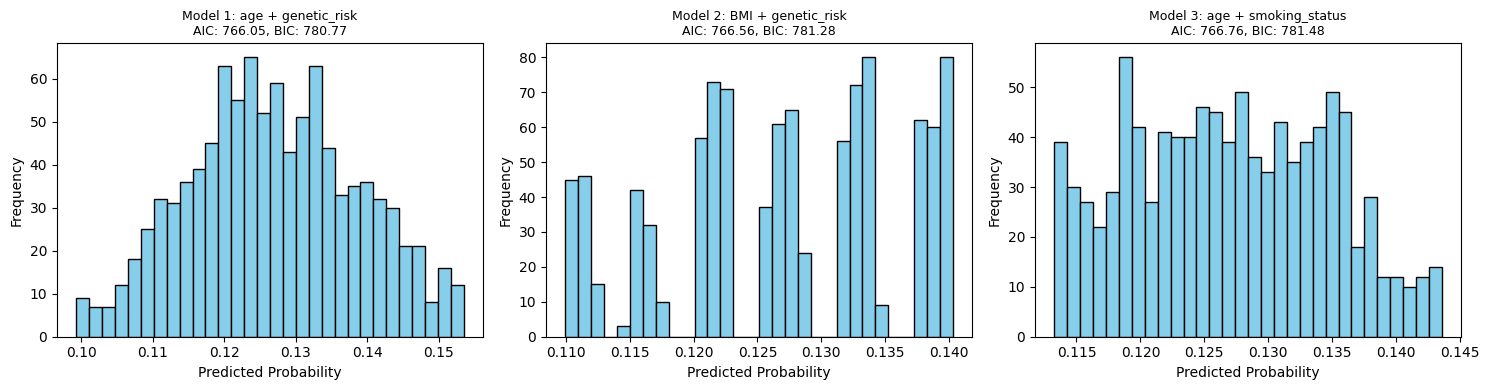


BEST MODEL DETAILS (continuous vars, by AIC):
                 Generalized Linear Model Regression Results                  
Dep. Variable:               diabetes   No. Observations:                 1000
Model:                            GLM   Df Residuals:                      997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -380.02
Date:                Thu, 12 Feb 2026   Deviance:                       760.05
Time:                        11:20:07   Pearson chi2:                     999.
No. Iterations:                     5   Pseudo R-squ. (CS):           0.001241
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
I

,age,BMI,smoking_status,genetic_risk,diabetes,predicted_prob
0,64,29.722920,0,2,0,0.116870
1,67,35.121296,0,3,0,0.110103
2,20,39.112930,0,3,0,0.133962
3,23,21.022390,0,2,0,0.138525
4,23,20.800589,0,0,1,0.151672
...,...,...,...,...,...,...
995,57,36.675337,0,3,0,0.114845
996,61,35.227835,1,3,0,0.112927
997,37,25.111939,1,0,1,0.143310
998,36,37.327384,0,1,1,0.137484



Coefficients:
 Intercept      -1.612261
age            -0.004752
genetic_risk   -0.053027
dtype: float64

Odds Ratios:
 Intercept       0.199436
age             0.995260
genetic_risk    0.948355
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from itertools import combinations

df = pd.read_csv('../data/patient.csv')
display(df)

# Wybranie nazw kolumn do wytyczenia najlepszego równania regresji logistycznej
predictors = [col for col in df.columns if col != 'diabetes']

# Określenie które kolumny są zmiennymi ciągłymi (te z dużą liczbą unikalnych wartości, w tym wypadku > 10 - potrzebne do histogramu z gładką krzywą)
continuous_vars = [col for col in predictors if df[col].nunique() > 10]
print(f"Continuous variables (for smooth histogram): {continuous_vars}")

results = []
# Szukamy równania dwóch zmiennych
for r in range(2, len(predictors) + 1):
    for combo in combinations(predictors, r):
        formula = 'diabetes ~ ' + ' + '.join(combo)
        model = smf.glm(formula, data=df, family=sm.families.Binomial()).fit()
        # Szukamy równania dwóch zmiennych, które ma najlepsze AIC/BIC
        # i zawiera przynajmniej jedną zmienną ciągłą (dla gładkiego histogramu)
        has_continuous = any(var in combo for var in continuous_vars)
        results.append({
            'variables': ' + '.join(combo),
            'n_vars': len(combo),
            'AIC': np.round(model.aic, 2),
            'BIC': np.round(model.bic_llf, 2),
            'has_continuous': has_continuous
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AIC').reset_index(drop=True)
print("\nAll models sorted by AIC (lower is better):")
display(results_df)

results_continuous = results_df[results_df['has_continuous'] == True].reset_index(drop=True)
print("\nModels with continuous variables (for smooth histogram):")
display(results_continuous)

best_vars = results_continuous.iloc[0]['variables']
print(f"\nBest model (continuous, by AIC): {best_vars}")

results_continuous_bic = results_continuous.sort_values('BIC').reset_index(drop=True)
best_bic_vars = results_continuous_bic.iloc[0]['variables']
print(f"Best model (continuous, by BIC): {best_bic_vars}")

top_3 = results_continuous.head(3)
print("\nTop 3 models:")
display(top_3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, row in top_3.iterrows():
    vars_str = row['variables']
    formula = f'diabetes ~ {vars_str}'
    model = smf.glm(formula, data=df, family=sm.families.Binomial()).fit()
    probs = model.predict(df)

    axes[i].hist(probs, bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Model {i+1}: {vars_str}\nAIC: {row["AIC"]}, BIC: {row["BIC"]}', fontsize=9)
    axes[i].set_xlabel('Predicted Probability')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("BEST MODEL DETAILS (continuous vars, by AIC):")
print("="*60)
best_formula = f'diabetes ~ {best_vars}'
best_model = smf.glm(best_formula, data=df, family=sm.families.Binomial()).fit()
print(best_model.summary())
print(f'\nAIC: {np.round(best_model.aic, 2)}')
print(f'BIC: {np.round(best_model.bic_llf, 2)}')

df['predicted_prob'] = best_model.predict(df)
display(df)

print("\nCoefficients:\n", best_model.params)

odds_ratios = np.exp(best_model.params)
print("\nOdds Ratios:\n", odds_ratios)